# Preliminary Model Benchmark Visualization

This notebook visualizes benchmark outputs from `eval/run_models_bench.py`.
It expects `eval/bench_results.csv` to exist.

## run benchmark

In [20]:
!cd ../ && python eval/run_models_bench.py

Config file: eval/eval_config.txt
Prompts loaded: 3
Repetitions: 2, Warmup prompts: 1

== Benchmarking: models/qwen3_5-9b-q8_0.gguf (port 8088) ==
Server ready. Log: logs/eval/server_qwen3_5-9b-q8_0_1774330898.log
  warmup 1/1 complete
  rep=1 prompt=1: TTFT=109.33 ms, TPOT(chunk)=42.14 ms, RSS_peak=1.49 GB, VRAM_peak=8.86 GB, GPU=0
  rep=1 prompt=2: TTFT=97.01 ms, TPOT(chunk)=42.23 ms, RSS_peak=1.50 GB, VRAM_peak=8.86 GB, GPU=0
  rep=1 prompt=3: TTFT=93.67 ms, TPOT(chunk)=42.31 ms, RSS_peak=1.50 GB, VRAM_peak=8.86 GB, GPU=0
  rep=2 prompt=1: TTFT=110.80 ms, TPOT(chunk)=42.25 ms, RSS_peak=1.55 GB, VRAM_peak=8.86 GB, GPU=0
  rep=2 prompt=2: TTFT=110.12 ms, TPOT(chunk)=42.21 ms, RSS_peak=1.61 GB, VRAM_peak=8.86 GB, GPU=0
  rep=2 prompt=3: TTFT=107.51 ms, TPOT(chunk)=42.24 ms, RSS_peak=1.66 GB, VRAM_peak=8.86 GB, GPU=0

== Benchmarking: models/qwen3_5-9b-q6_K.gguf (port 8089) ==
Server ready. Log: logs/eval/server_qwen3_5-9b-q6_K_1774330936.log
  warmup 1/1 complete
  rep=1 prompt=1: TTFT

## visualization

## measured columns (what each means)

- `model_file`: GGUF filename being benchmarked.
- `model_path`: workspace-relative path to the GGUF file (not absolute).
- `repetition`: repeat index for the same prompt/model pair.
- `prompt_index`: 1-based index of the prompt in the loaded prompt list.
- `prompt_preview`: first ~120 chars of the prompt for quick inspection.
- `ttft_ms`: Time To First Token in milliseconds.
- `tpot_ms_per_chunk`: average milliseconds between streamed chunks after first token.
- `tpot_ms_per_word`: average milliseconds per generated word after first token.
- `e2e_latency_ms`: total request latency from send to final token.
- `output_chars`: generated output size in characters.
- `output_words`: generated output size in words.
- `chunks_seen`: number of streamed chunks received.
- `peak_rss_gb`: peak process resident memory (RAM) in GB while serving request.
- `peak_vram_gb`: peak total VRAM used by the serving process across all GPUs in GB.
- `gpu_indices`: GPU index(es) used (joined with `|` when multiple).
- `gpu_names`: GPU model name(s) used.
- `gpu_uuids`: GPU UUID(s) used.
- `peak_vram_by_gpu_json`: JSON map of per-GPU peak VRAM in GB.
- `temperature`, `n_predict`, `ctx_size`: generation settings used for that row.

In [21]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

csv_path = Path('./bench_results.csv')
if not csv_path.exists():
    raise FileNotFoundError(f'Missing benchmark CSV: {csv_path}. Run eval/run_models_bench.py first.')

df = pd.read_csv(csv_path)
df.head()

,model_path,model_file,repetition,prompt_index,prompt_preview,ttft_ms,tpot_ms_per_chunk,tpot_ms_per_word,e2e_latency_ms,output_chars,...,chunks_seen,peak_rss_gb,peak_vram_gb,gpu_indices,gpu_names,gpu_uuids,peak_vram_by_gpu_json,temperature,n_predict,ctx_size
0,models/qwen3_5-9b-q8_0.gguf,qwen3_5-9b-q8_0.gguf,1,1,Explain gradient descent in 3 concise bullet p...,109.331281,42.143923,55.715695,3581.815960,396,...,79,1.493462,8.855469,0,NVIDIA GB10,GPU-3670d735-9d05-3d69-00e6-9a72552efb03,"{""0"": 8.85546875}",0.1,128,4096
1,models/qwen3_5-9b-q8_0.gguf,qwen3_5-9b-q8_0.gguf,1,2,What is overfitting and how do you mitigate it?,97.009208,42.230256,52.070315,5606.682450,668,...,128,1.496326,8.855469,0,NVIDIA GB10,GPU-3670d735-9d05-3d69-00e6-9a72552efb03,"{""0"": 8.85546875}",0.1,128,4096
2,models/qwen3_5-9b-q8_0.gguf,qwen3_5-9b-q8_0.gguf,1,3,Compare precision and recall briefly.,93.672549,42.310761,50.693082,5572.889974,726,...,128,1.502586,8.855469,0,NVIDIA GB10,GPU-3670d735-9d05-3d69-00e6-9a72552efb03,"{""0"": 8.85546875}",0.1,128,4096
3,models/qwen3_5-9b-q8_0.gguf,qwen3_5-9b-q8_0.gguf,2,1,Explain gradient descent in 3 concise bullet p...,110.799633,42.251713,52.972297,3850.853644,429,...,85,1.554466,8.857422,0,NVIDIA GB10,GPU-3670d735-9d05-3d69-00e6-9a72552efb03,"{""0"": 8.857421875}",0.1,128,4096
4,models/qwen3_5-9b-q8_0.gguf,qwen3_5-9b-q8_0.gguf,2,2,What is overfitting and how do you mitigate it?,110.116895,42.209226,54.147188,5538.821997,640,...,128,1.607861,8.857422,0,NVIDIA GB10,GPU-3670d735-9d05-3d69-00e6-9a72552efb03,"{""0"": 8.857421875}",0.1,128,4096


In [22]:
numeric_cols = [
    'ttft_ms',
    'tpot_ms_per_chunk',
    'tpot_ms_per_word',
    'peak_rss_gb',
    'peak_vram_gb',
    'e2e_latency_ms',
]
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

summary = (
    df.groupby('model_file', dropna=False)
      .agg(
          samples=('model_file', 'count'),
          ttft_ms_mean=('ttft_ms', 'mean'),
          ttft_ms_p95=('ttft_ms', lambda s: s.quantile(0.95)),
          tpot_chunk_mean=('tpot_ms_per_chunk', 'mean'),
          tpot_chunk_p95=('tpot_ms_per_chunk', lambda s: s.quantile(0.95)),
          peak_rss_gb_max=('peak_rss_gb', 'max'),
          peak_vram_gb_max=('peak_vram_gb', 'max'),
      )
      .sort_values('ttft_ms_mean')
      .reset_index()
)
summary

,model_file,samples,ttft_ms_mean,ttft_ms_p95,tpot_chunk_mean,tpot_chunk_p95,peak_rss_gb_max,peak_vram_gb_max
0,qwen3_5-9b-q4_0.gguf,6,68.710961,75.026671,25.008788,25.123827,1.186829,5.406250
1,qwen3_5-9b-q4_K_M.gguf,6,77.544103,83.101645,28.898714,28.934705,1.189293,5.703125
2,qwen3_5-9b-q5_K_M.gguf,6,85.159158,90.831087,32.943099,32.998207,1.307503,6.365234
3,qwen3_5-9b-q6_K.gguf,6,94.333984,100.091239,37.060707,37.145948,1.431217,7.067383
4,qwen3_5-9b-q8_0.gguf,6,104.739951,110.628948,42.230928,42.295999,1.661083,8.857422


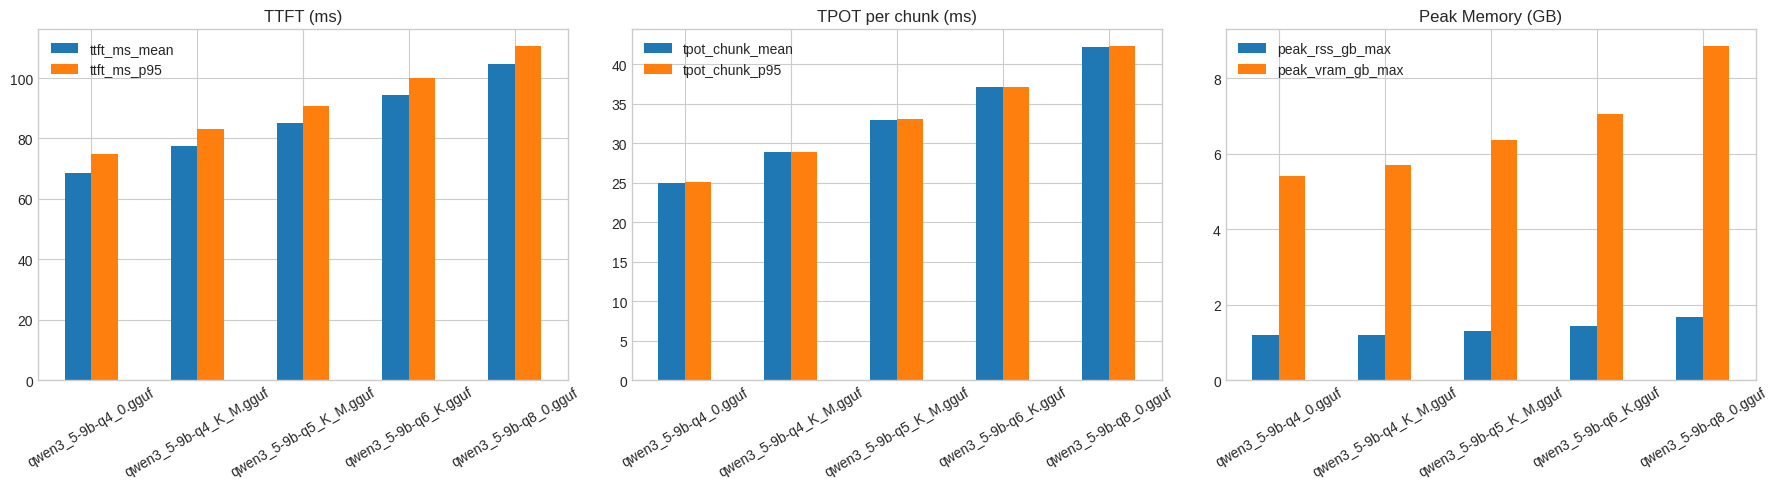

In [23]:
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

summary.plot(
    x='model_file',
    y=['ttft_ms_mean', 'ttft_ms_p95'],
    kind='bar',
    ax=axes[0],
    title='TTFT (ms)',
)
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=30)

summary.plot(
    x='model_file',
    y=['tpot_chunk_mean', 'tpot_chunk_p95'],
    kind='bar',
    ax=axes[1],
    title='TPOT per chunk (ms)',
)
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=30)

summary.plot(
    x='model_file',
    y=['peak_rss_gb_max', 'peak_vram_gb_max'],
    kind='bar',
    ax=axes[2],
    title='Peak Memory (GB)',
)
axes[2].set_xlabel('')
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

,gpu_index,samples
0,0,30


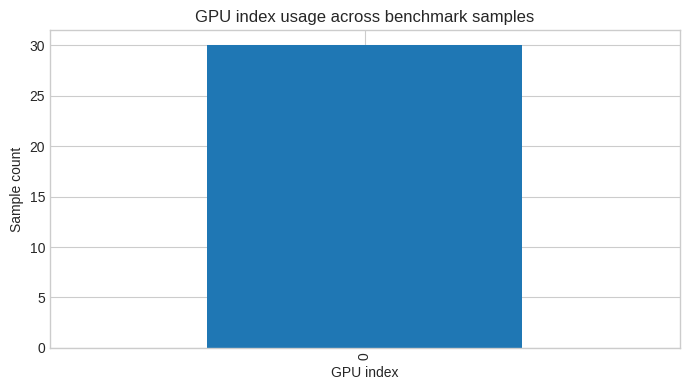

In [24]:
if 'gpu_indices' in df.columns:
    gpu_counts = (
        df['gpu_indices']
          .fillna('unknown')
          .astype(str)
          .str.split('|')
          .explode()
          .str.strip()
          .replace('', 'unknown')
          .value_counts()
          .rename_axis('gpu_index')
          .reset_index(name='samples')
    )

    display(gpu_counts)

    ax = gpu_counts.plot(
        x='gpu_index',
        y='samples',
        kind='bar',
        figsize=(7, 4),
        legend=False,
        title='GPU index usage across benchmark samples',
    )
    ax.set_xlabel('GPU index')
    ax.set_ylabel('Sample count')
    plt.tight_layout()
    plt.show()
else:
    print('No GPU columns found in CSV. Re-run eval/run_models_bench.py with latest version.')